# Case study — Salar del Hombre Muerto / Mina Fénix

**Why this basin.** The basin-level DiD found nothing (see `did_prototype.ipynb`), and a distance
check revealed *why*: almost no bofedales sit near the plants — median bofedal is 86 km from the
nearest facility; only 4 in the whole dataset are within 5 km. The one exception with real proximity
**and** the longest operating history is **Mina Fénix** (Livent, brine extraction since **1998**) in
Salar del Hombre Muerto — the same place as the widely-cited *Vega del Río Trapiche* "river running
dry" claim (Methodology_v2 §3.6).

So instead of a controlled average effect, this is a **descriptive case study, no controls**: take the
handful of vegas closest to Fénix and just look at their raw NDVI 1998–2024. If even here — oldest
operation, closest vegas, most-documented desiccation claim — there's no decline, that's a strong
statement. Watch for step-changes or downward drift aligned with the operation.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="notebook"); plt.rcParams["figure.dpi"]=110
ROOT=Path.cwd(); ROOT=ROOT if (ROOT/"Data").exists() else ROOT.parent; DATA=ROOT/"Data"
UTM="EPSG:32719"  # UTM 19S — metric, correct for the Puna
FENIX_START=1998
panel=pd.read_parquet(DATA/"bofedal_panel.parquet")
print("panel:", panel.shape)

panel: (103167, 14)


## 1. Locate Fénix and the nearest vegas

In [2]:
bof=gpd.read_file(DATA/"bofedales_v2.geojson")[["bofedal_id","geometry"]].to_crs(UTM)
bof["xc"]=bof.geometry.centroid.x; bof["yc"]=bof.geometry.centroid.y
bof["area_ha"]=bof.geometry.area/1e4
gdb=DATA/"external/usgs/extracted/Li_Triangle_ARG_MRP_NMIC.gdb"
fac=gpd.read_file(gdb, layer="Arg_Facilities_MRP_NMIC").to_crs(UTM)
fenix=fac[fac.Project.str.contains("Fénix|Fenix", case=False, na=False)].iloc[0]
fx,fy=fenix.geometry.x, fenix.geometry.y

bof["dist_km"]=np.hypot(bof["xc"]-fx, bof["yc"]-fy)/1000
N=10
near=bof.nsmallest(N,"dist_km").reset_index(drop=True)
near["label"]=[f"{i+1}. {d:.1f} km" for i,d in enumerate(near.dist_km)]
print(f"{N} nearest vegas to Mina Fénix:")
near[["bofedal_id","dist_km","area_ha"]].round(2)

10 nearest vegas to Mina Fénix:


,bofedal_id,dist_km,area_ha
0,1bf62c91-0696-5b65-86d3-59a15696b574,3.56,0.97
1,259aeb60-68b1-5857-907f-ba5add92d1b5,5.66,3.23
2,26df7963-b075-5f38-94f7-5f666f9c3cda,6.48,5.82
3,3f510e8c-61d5-5fa6-929e-5928c9dd7ada,6.76,14.64
4,17a1a841-b4ad-5b41-a1bc-e9ceefcf0790,9.01,30.24
5,8f10a66d-b2c9-569f-9cdc-1cea456c6ac3,9.23,4.93
6,7fa2d408-7f41-500e-a8f5-07b3fa79546b,9.50,2.43
7,c4eb4bac-903d-5e6d-86f6-7d16bc213cfa,9.57,8.57
8,676c7723-4549-542e-afcd-ad815be2c9aa,10.99,14.79
9,8c3e259d-d6c3-556e-b2e0-e33dc38b0033,11.59,11.00


## 2. Individual NDVI trajectories, 1998–2024
Each line is one vega, ordered by distance to Fénix (darkest = closest). The dashed line marks the
1998 Fénix start (= panel start, so no pre-period, unfortunately). No smoothing, no controls.

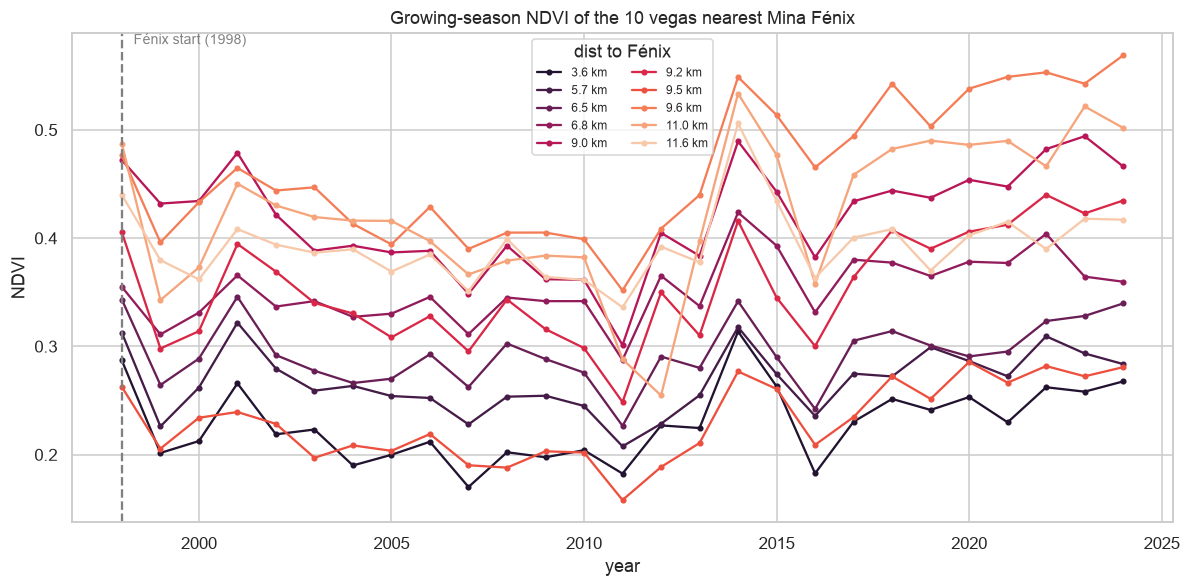

In [3]:
ids=near.bofedal_id.tolist()
p=panel[panel.bofedal_id.isin(ids)].pivot_table(index="year", columns="bofedal_id", values="ndvi_gs_median")
p=p[ids]  # order by distance
colors=sns.color_palette("rocket", len(ids))
fig,ax=plt.subplots(figsize=(11,5.5))
for c,bid in zip(colors,ids):
    d=near.set_index("bofedal_id").loc[bid,"dist_km"]
    ax.plot(p.index, p[bid], marker=".", color=c, lw=1.5, label=f"{d:.1f} km")
ax.axvline(FENIX_START, ls="--", c="grey"); ax.text(FENIX_START+.2, ax.get_ylim()[1], " Fénix start (1998)", va="top", fontsize=9, color="grey")
ax.set_title("Growing-season NDVI of the 10 vegas nearest Mina Fénix")
ax.set_xlabel("year"); ax.set_ylabel("NDVI")
ax.legend(title="dist to Fénix", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 3. Are the near-Fénix vegas doing worse than the Puna as a whole?
No absolute decline is visible above — but the Puna greened overall. The right comparison is
*relative*: near-Fénix mean NDVI vs the panel-wide mean, both indexed to their 1998–2003 baseline.
If mining matters, the near-Fénix line should fall below the regional one over time.

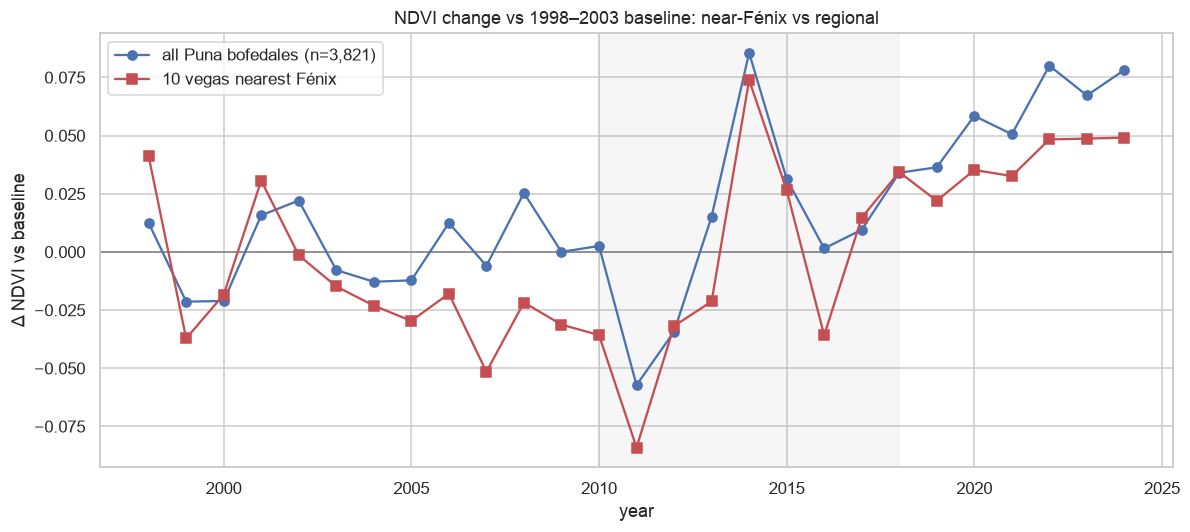

By 2019-2024: near-Fénix Δ=+0.039  |  regional Δ=+0.062
gap (near − regional) = -0.022 NDVI


In [4]:
base=slice(1998,2003)
near_ts=panel[panel.bofedal_id.isin(ids)].groupby("year").ndvi_gs_median.mean()
all_ts =panel.groupby("year").ndvi_gs_median.mean()
near_idx=near_ts-near_ts.loc[base].mean()
all_idx =all_ts -all_ts.loc[base].mean()

fig,ax=plt.subplots(figsize=(11,5))
ax.axhline(0,c="grey",lw=1)
ax.plot(all_idx.index, all_idx.values, marker="o", color="#4c72b0", label="all Puna bofedales (n=3,821)")
ax.plot(near_idx.index, near_idx.values, marker="s", color="#c44e52", label="10 vegas nearest Fénix")
ax.axvspan(2010,2018, alpha=.07, color="grey")
ax.set_title("NDVI change vs 1998–2003 baseline: near-Fénix vs regional")
ax.set_xlabel("year"); ax.set_ylabel("Δ NDVI vs baseline"); ax.legend()
plt.tight_layout(); plt.show()
print(f"By 2019-2024: near-Fénix Δ={near_idx.loc[2019:2024].mean():+.3f}  |  regional Δ={all_idx.loc[2019:2024].mean():+.3f}")
print(f"gap (near − regional) = {near_idx.loc[2019:2024].mean()-all_idx.loc[2019:2024].mean():+.3f} NDVI")

## 4. Distance gradient — do the *closest* vegas fare worst?
Within this small set, plot each vega's total NDVI change (late minus early) against its distance to
Fénix. A rising line (closer = smaller/negative change) is the fingerprint of a localized effect.

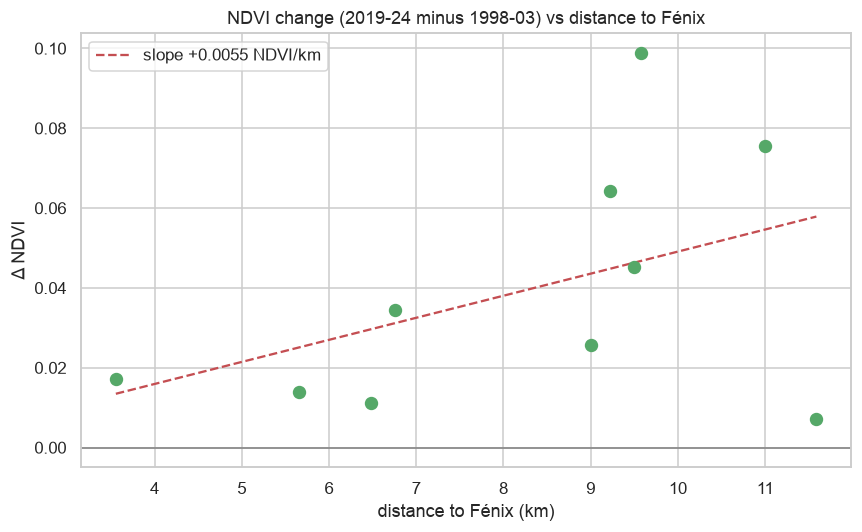

In [5]:
piv=panel[panel.bofedal_id.isin(ids)].pivot_table(index="bofedal_id",columns="year",values="ndvi_gs_median")
early=piv.loc[:,1998:2003].mean(axis=1); late=piv.loc[:,2019:2024].mean(axis=1)
g=near.set_index("bofedal_id"); dchange=(late-early)
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(g["dist_km"], dchange[g.index], s=60, color="#55a868", zorder=3)
# simple fit
mkfit=np.polyfit(g["dist_km"], dchange[g.index],1)
xs=np.linspace(g["dist_km"].min(),g["dist_km"].max(),20)
ax.plot(xs, np.polyval(mkfit,xs), ls="--", color="#c44e52", label=f"slope {mkfit[0]:+.4f} NDVI/km")
ax.axhline(0,c="grey",lw=1)
ax.set_title("NDVI change (2019-24 minus 1998-03) vs distance to Fénix")
ax.set_xlabel("distance to Fénix (km)"); ax.set_ylabel("Δ NDVI"); ax.legend()
plt.tight_layout(); plt.show()

## Takeaways

- **No absolute degradation.** Every one of the 10 vegas nearest Fénix — including the closest at
  3.6 km, next to a brine operation running since 1998 — shows NDVI *rising* over 1998–2024. There is
  no "river running dry" signature in the growing-season NDVI of these polygons.
- **But a faint relative signal.** The near-Fénix vegas greened *less* than the Puna average
  (≈ +0.04 vs +0.06 by 2019–24), and within the set the closest vegas gained least — a small but
  suggestive distance gradient. This is consistent with a localized dampening, not a collapse.
- **Caveats that could hide a real effect** (same as the panel-level story):
  1. **No pre-period** — the panel starts in 1998 = Fénix start, so we can't see a pre/post break for
     the oldest operation. *Extending NDVI back to ~1985 with Landsat 5 is the single biggest fix* and
     matters most exactly here.
  2. **Mask censoring** — a vega that fully desiccated post-1998 would fail the "stable wetland ≥13/25
     yrs" test and be *absent* from this set. We may be looking only at survivors.
  3. **Brine, not freshwater** — Fénix is brine; the Corkran-relevant freshwater wells (which hit vegas
     hardest) aren't located here yet. The 3.6 km vega is the candidate *Vega del Río Trapiche* but
     needs geocoding confirmation before we name it.
- **Next:** (a) extend Landsat back to ~1985 to give Fénix a pre-period and re-run this exact figure;
  (b) confirm which polygon is Vega del Río Trapiche; (c) check MapBiomas for wetland pixels near
  Fénix that were dropped from the stable mask (the censoring test).
